In [1]:
"""
A1. Low-rank scaling and accuracy tests (Classical)
---------------------------------------------------
This notebook tests and benchmarks the classical Type-II NUFFT low-rank
implementation against the dense NUDT reference.

It generates representative nonuniform node sets (perturbed equispaced,
clustered, and random), computes the perturbation parameter gamma via
assign_closest_equispaced_gridpoint and perturbation_parameter, determines
the expansion rank parameter k using find_k, and applies the planned
low-rank NUFFT (plan_nufft2 / nufft2).

For each problem size N = 2^n and multiple random complex input vectors,
it compares the low-rank NUFFT result against the dense reference
(nudft_type2_dense), measuring:
    - relative ℓ2 error,
    - maximum absolute error,
    - runtime for test and reference methods.

The experiment studies accuracy and scaling behavior as N increases,
and produces summary statistics and figures.
"""

import _init_path
import os
import argparse
import json
import time
from pathlib import Path
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple, Any

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import lambertw

# Classical methods
from classical.nudft_II import nudft_type2_dense

from classical import nufft_II_lowrank as nufft_lowrank
from classical.nufft_II_lowrank import (
    plan_nufft2,
    nufft2,
    assign_closest_equispaced_gridpoint,
    perturbation_parameter,
    find_k,
)

# Datasets
from datasets.data import (
    nodes_uniform,
    nodes_random,
    nodes_perturbed_uniform,
    nodes_near_colliding,
    nodes_clustered,
)

from datasets.signals import signal_random_complex

# Utilities
from utils import rel_l2, max_abs, _apply_publication_rcparams, _force_opaque

Repo root: /Users/junaida/Documents/Non-Uniform-QFT
Added to sys.path: /Users/junaida/Documents/Non-Uniform-QFT/src


In [2]:
# ---------------------------------------------------------------------
# Global configuration defaults
# ---------------------------------------------------------------------
EPS_DEFAULT: float = 1e-15
REL_TOL_DEFAULT: float = 5e-12
ABS_TOL_DEFAULT: float = 5e-12
N_DEFAULT: int = 2**8
SEED_DEFAULT: int = 0


# ---------------------------------------------------------------------
# Result model
# ---------------------------------------------------------------------
@dataclass
class CheckResult:
    name: str
    rel_l2: float
    max_abs: float
    rel_tol: float
    abs_tol: float
    ok: bool
    t_test_s: float
    t_ref_s: float
    notes: str = ""


@dataclass
class SuiteResult:
    results: List[CheckResult]

    @property
    def n_total(self) -> int:
        return len(self.results)

    @property
    def n_failed(self) -> int:
        return sum(1 for r in self.results if not r.ok)

    @property
    def n_passed(self) -> int:
        return self.n_total - self.n_failed


# ---------------------------------------------------------------------
# Utilities: printing / formatting
# ---------------------------------------------------------------------
def _fmt_float(x: float) -> str:
    """Format a floating-point number into a compact scientific notation string.

    This routine converts a float into a readable string representation using
    scientific notation with three decimal digits. Special cases such as NaN
    and zero are handled explicitly.

    Args:
        x: Floating-point number to format.

    Returns:
        A string representing the formatted floating-point number.

    Raises:
        None.
    """
    if np.isnan(x):
        return "nan"
    if x == 0.0:
        return "0"
    return f"{x:.3e}"


def print_table(results: List[CheckResult]) -> None:
    """Print a compact box-style ASCII table of check results.

    This routine renders a boxed ASCII table summarizing the status and error
    metrics for each CheckResult in the provided list.

    Args:
        results: List of CheckResult objects to display.

    Returns:
        None.

    Raises:
        None.
    """
    headers = ["#", "Test", "Status", "rel_l2", "max_abs", "rel_tol", "abs_tol"]
    aligns = ["R", "L", "C", "R", "R", "R", "R"]

    rows: List[List[str]] = []
    for i, r in enumerate(results, 1):
        rows.append(
            [
                str(i),
                r.name,
                "PASS" if r.ok else "FAIL",
                _fmt_float(r.rel_l2),
                _fmt_float(r.max_abs),
                _fmt_float(r.rel_tol),
                _fmt_float(r.abs_tol),
            ]
        )

    # column widths
    widths = [len(h) for h in headers]
    for row in rows:
        for j, cell in enumerate(row):
            widths[j] = max(widths[j], len(cell))

    # box drawing
    TL, TR, BL, BR = "┌", "┐", "└", "┘"
    H, V = "─", "│"
    TJ, BJ, LJ, RJ, CJ = "┬", "┴", "├", "┤", "┼"

    def hline(left: str, mid: str, right: str) -> str:
        return left + mid.join(H * (w + 2) for w in widths) + right

    def format_cell(text: str, w: int, align: str, header: bool = False) -> str:
        if header:
            return f" {text:^{w}} "
        if align == "R":
            return f" {text:>{w}} "
        if align == "C":
            return f" {text:^{w}} "
        return f" {text:<{w}} "

    def render_row(row: List[str], header: bool = False) -> str:
        return (
            V
            + V.join(
                format_cell(row[j], widths[j], aligns[j], header=header)
                for j in range(len(headers))
            )
            + V
        )

    print(hline(TL, TJ, TR))
    print(render_row(headers, header=True))
    print(hline(LJ, CJ, RJ))
    for row in rows:
        print(render_row(row))
    print(hline(BL, BJ, BR))


def to_jsonable(results: List[CheckResult]) -> List[Dict[str, Any]]:
    """Convert check results into JSON-serializable dictionaries.

    This routine transforms a list of CheckResult objects into a list of plain
    Python dictionaries suitable for JSON serialization.

    Args:
        results: List of CheckResult objects.

    Returns:
        A list of dictionaries containing only JSON-serializable values.

    Raises:
        None.
    """
    out: List[Dict[str, Any]] = []
    for r in results:
        out.append(
            {
                "name": r.name,
                "rel_l2": float(r.rel_l2),
                "max_abs": float(r.max_abs),
                "rel_tol": float(r.rel_tol),
                "abs_tol": float(r.abs_tol),
                "ok": bool(r.ok),
                "t_test_s": float(r.t_test_s),
                "t_ref_s": float(r.t_ref_s),
                "notes": r.notes,
            }
        )
    return out


# ---------------------------------------------------------------------
# Core check: evaluate test + reference, compute errors and timing
# ---------------------------------------------------------------------
def run_check(
    name: str,
    make_data: Callable[[], Tuple[np.ndarray, np.ndarray]],
    test_fn: Callable[[np.ndarray, np.ndarray], np.ndarray],
    ref_fn: Callable[[np.ndarray, np.ndarray], np.ndarray],
    rel_tol: float,
    abs_tol: float,
    repeat: int = 1,
    notes: str = "",
) -> CheckResult:
    """Execute a single test check and compute accuracy and timing metrics.

    This routine generates input data, evaluates both the test and reference
    methods, measures execution times, computes relative L2 and maximum
    absolute errors, and determines pass/fail status.

    Args:
        name: Name of the test case.
        make_data: Callable returning a tuple (x, c) of NumPy arrays.
        test_fn: Callable implementing the method under test.
        ref_fn: Callable implementing the reference method.
        rel_tol: Relative L2 error tolerance.
        abs_tol: Maximum absolute error tolerance.
        repeat: Number of timing repetitions (minimum time retained).
        notes: Optional descriptive notes for the test.

    Returns:
        A CheckResult object containing error metrics, timing, and pass status.

    Raises:
        AssertionError: If either test or reference output is None.
    """
    # Data is generated once per check to keep comparability between methods.
    x, c = make_data()

    # Timings: run multiple times and take minimum to reduce noise.
    f_test: Optional[np.ndarray] = None
    t_test_best = float("inf")
    for _ in range(max(1, repeat)):
        t0 = time.perf_counter()
        f_test = test_fn(x, c)
        t1 = time.perf_counter()
        t_test_best = min(t_test_best, t1 - t0)

    f_ref: Optional[np.ndarray] = None
    t_ref_best = float("inf")
    for _ in range(max(1, repeat)):
        t0 = time.perf_counter()
        f_ref = ref_fn(x, c)
        t1 = time.perf_counter()
        t_ref_best = min(t_ref_best, t1 - t0)

    assert f_test is not None and f_ref is not None

    r = rel_l2(f_test, f_ref)
    m = max_abs(f_test, f_ref)
    ok = (r <= rel_tol) and (m <= abs_tol)

    return CheckResult(
        name=name,
        rel_l2=float(r),
        max_abs=float(m),
        rel_tol=float(rel_tol),
        abs_tol=float(abs_tol),
        ok=bool(ok),
        t_test_s=float(t_test_best),
        t_ref_s=float(t_ref_best),
        notes=notes,
    )


# ---------------------------------------------------------------------
# Test suite definition
# ---------------------------------------------------------------------
def build_suite(
    N: int,
    eps: float,
    rng: np.random.Generator,
    rel_tol: float,
    abs_tol: float,
) -> List[Dict[str, Any]]:
    """Construct the list of test specifications for the NUFFT test suite.

    This routine defines a collection of structured test cases, including
    uniform grids, random nodes, perturbed nodes, impulse responses, and
    geometrically challenging configurations. Each test specification contains
    data generation, test/reference functions, tolerances, and optional notes.

    Args:
        N: Problem size.
        eps: Accuracy parameter for the low-rank NUFFT.
        rng: NumPy random number generator.
        rel_tol: Default relative L2 tolerance.
        abs_tol: Default maximum absolute tolerance.

    Returns:
        A list of dictionaries describing test specifications.

    Raises:
        None.
    """

    def lr(x: np.ndarray, c: np.ndarray) -> np.ndarray:
        return nufft2(c, x, eps, None)

    def dense(x: np.ndarray, c: np.ndarray) -> np.ndarray:
        return nudft_type2_dense(x, c)

    suite: List[Dict[str, Any]] = []

    # A) Uniform grid sanity: equals FFT
    suite.append(
        dict(
            name="uniform: lowrank vs dense",
            make_data=lambda: (nodes_uniform(N), signal_random_complex(N, rng=rng)),
            test_fn=lr,
            ref_fn=dense,
            rel_tol=rel_tol,
            abs_tol=abs_tol,
            notes="sanity",
        )
    )

    suite.append(
        dict(
            name="uniform: dense vs fft",
            make_data=lambda: (nodes_uniform(N), signal_random_complex(N, rng=rng)),
            test_fn=lambda x, c: dense(x, c),
            ref_fn=lambda x, c: np.fft.fft(c),
            rel_tol=1e-11,
            abs_tol=1e-11,
            notes="FFT equivalence",
        )
    )

    suite.append(
        dict(
            name="uniform: lowrank vs fft",
            make_data=lambda: (nodes_uniform(N), signal_random_complex(N, rng=rng)),
            test_fn=lambda x, c: lr(x, c),
            ref_fn=lambda x, c: np.fft.fft(c),
            rel_tol=rel_tol,
            abs_tol=abs_tol,
            notes="FFT equivalence",
        )
    )

    # B) Random nonuniform nodes: lowrank vs dense
    suite.append(
        dict(
            name="random nodes: lowrank vs dense",
            make_data=lambda: (
                nodes_random(N, rng=rng),
                signal_random_complex(N, rng=rng),
            ),
            test_fn=lr,
            ref_fn=dense,
            rel_tol=rel_tol,
            abs_tol=abs_tol,
        )
    )

    # C) Perturbed uniform nodes (small jitter): lowrank vs dense
    suite.append(
        dict(
            name="perturbed uniform: lowrank vs dense",
            make_data=lambda: (
                nodes_perturbed_uniform(N, jitter=0.2 / N, rng=rng),
                signal_random_complex(N, rng=rng),
            ),
            test_fn=lr,
            ref_fn=dense,
            rel_tol=rel_tol,
            abs_tol=abs_tol,
        )
    )

    # D) Known-answer: impulse response
    def make_impulse_data() -> Tuple[np.ndarray, np.ndarray]:
        x = nodes_random(N, rng=rng)
        c = np.zeros(N, dtype=complex)
        c[7] = 1.0 + 0.0j
        return x, c

    def expected_impulse(x: np.ndarray, c: np.ndarray) -> np.ndarray:
        j0 = int(np.argmax(np.abs(c)))
        k = np.arange(N, dtype=float)
        return np.exp(-2j * np.pi * x[j0] * k)

    suite.append(
        dict(
            name="impulse: dense vs expected",
            make_data=make_impulse_data,
            test_fn=lambda x, c: dense(x, c),
            ref_fn=lambda x, c: expected_impulse(x, c),
            rel_tol=1e-13,
            abs_tol=1e-12,
            notes="known answer",
        )
    )

    suite.append(
        dict(
            name="impulse: lowrank vs expected",
            make_data=make_impulse_data,
            test_fn=lambda x, c: lr(x, c),
            ref_fn=lambda x, c: expected_impulse(x, c),
            rel_tol=rel_tol,
            abs_tol=abs_tol,
            notes="known answer",
        )
    )

    # E) “Harder” geometries: near-colliding / clustered
    suite.append(
        dict(
            name="near-colliding: lowrank vs dense",
            make_data=lambda: (
                nodes_near_colliding(N, min_sep=1e-4, rng=rng),
                signal_random_complex(N, rng=rng),
            ),
            test_fn=lr,
            ref_fn=dense,
            rel_tol=rel_tol,
            abs_tol=abs_tol,
            notes="hard geometry",
        )
    )

    suite.append(
        dict(
            name="clustered: lowrank vs dense",
            make_data=lambda: (
                nodes_clustered(N, n_clusters=3, cluster_std=0.01, rng=rng),
                signal_random_complex(N, rng=rng),
            ),
            test_fn=lr,
            ref_fn=dense,
            rel_tol=rel_tol,
            abs_tol=abs_tol,
            notes="hard geometry",
        )
    )

    return suite


# ---------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------
def main() -> None:
    """Execute the full NUFFT Type-II low-rank test suite.

    This routine parses command-line arguments, builds the test suite, executes
    all checks, prints formatted summaries, optionally writes a JSON report,
    optionally generates plots, and exits with nonzero status if any tests fail.

    Args:
        None.

    Returns:
        None.

    Raises:
        SystemExit: If one or more tests fail.
    """
    parser = argparse.ArgumentParser(add_help=True)
    parser.add_argument("--N", type=int, default=N_DEFAULT)
    parser.add_argument("--eps", type=float, default=EPS_DEFAULT)
    parser.add_argument("--rel-tol", type=float, default=REL_TOL_DEFAULT)
    parser.add_argument("--abs-tol", type=float, default=ABS_TOL_DEFAULT)
    parser.add_argument("--seed", type=int, default=SEED_DEFAULT)
    parser.add_argument(
        "--repeat", type=int, default=1, help="Repeat each method run and take min time."
    )
    parser.add_argument("--fail-fast", action="store_true", help="Stop at first failure.")
    parser.add_argument("--plot", action="store_true", help="Show/save plots.")
    parser.add_argument(
        "--plot-prefix", type=str, default=None, help="If set, save plots to files with this prefix."
    )
    parser.add_argument("--json-out", type=str, default=None, help="Write machine-readable results JSON.")

    # Jupyter/IPython injects extra CLI args (e.g. "-f kernel.json").
    # parse_known_args() ignores unknown flags so the script runs both in CLI and notebooks.
    args, _unknown = parser.parse_known_args()

    rng = np.random.default_rng(args.seed)
    suite_specs = build_suite(args.N, args.eps, rng, args.rel_tol, args.abs_tol)

    results: List[CheckResult] = []
    for spec in suite_specs:
        r = run_check(
            name=spec["name"],
            make_data=spec["make_data"],
            test_fn=spec["test_fn"],
            ref_fn=spec["ref_fn"],
            rel_tol=spec["rel_tol"],
            abs_tol=spec["abs_tol"],
            repeat=args.repeat,
            notes=spec.get("notes", ""),
        )
        results.append(r)

        if args.fail_fast and (not r.ok):
            break

    suite = SuiteResult(results=results)

    print_table(results)
    print(f"\nPassed: {suite.n_passed}/{suite.n_total}  Failed: {suite.n_failed}/{suite.n_total}")

    if args.json_out is not None:
        payload = {
            "N": args.N,
            "eps": args.eps,
            "rel_tol_default": args.rel_tol,
            "abs_tol_default": args.abs_tol,
            "seed": args.seed,
            "repeat": args.repeat,
            "passed": suite.n_passed,
            "failed": suite.n_failed,
            "results": to_jsonable(results),
        }
        with open(args.json_out, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)
        print(f"Wrote JSON report: {args.json_out}")

    if args.plot:
        plot_results(results, out_prefix=args.plot_prefix)

    if suite.n_failed > 0:
        raise SystemExit(1)


if __name__ == "__main__":
    main()

┌───┬─────────────────────────────────────┬────────┬───────────┬───────────┬───────────┬───────────┐
│ # │                Test                 │ Status │  rel_l2   │  max_abs  │  rel_tol  │  abs_tol  │
├───┼─────────────────────────────────────┼────────┼───────────┼───────────┼───────────┼───────────┤
│ 1 │ uniform: lowrank vs dense           │  PASS  │         0 │         0 │ 5.000e-12 │ 5.000e-12 │
│ 2 │ uniform: dense vs fft               │  PASS  │         0 │         0 │ 1.000e-11 │ 1.000e-11 │
│ 3 │ uniform: lowrank vs fft             │  PASS  │         0 │         0 │ 5.000e-12 │ 5.000e-12 │
│ 4 │ random nodes: lowrank vs dense      │  PASS  │ 4.292e-14 │ 1.235e-13 │ 5.000e-12 │ 5.000e-12 │
│ 5 │ perturbed uniform: lowrank vs dense │  PASS  │ 4.135e-14 │ 1.316e-13 │ 5.000e-12 │ 5.000e-12 │
│ 6 │ impulse: dense vs expected          │  PASS  │ 3.576e-14 │ 1.137e-13 │ 1.000e-13 │ 1.000e-12 │
│ 7 │ impulse: lowrank vs expected        │  PASS  │ 3.228e-14 │ 1.186e-13 │ 5.000e-12 │ 5.

In [3]:
# -----------------------------
# Utilities
# -----------------------------
def _rng(seed: int = 0) -> np.random.Generator:
    """Create a NumPy random number generator.

    This routine constructs a NumPy Generator instance using the provided seed.

    Args:
        seed: Seed used to initialize the random number generator.

    Returns:
        A NumPy random Generator.

    Raises:
        None.
    """
    return np.random.default_rng(seed)


def _complex_standard_normal(rng: np.random.Generator, n: int) -> np.ndarray:
    """Generate a standard complex normal random vector.

    This routine draws a vector distributed as CN(0, 1), implemented as
    (a + i b) / sqrt(2) with a, b ~ N(0, 1) i.i.d.

    Args:
        rng: NumPy random number generator.
        n: Length of the output vector.

    Returns:
        A complex-valued NumPy array of length n.

    Raises:
        None.
    """
    # CN(0,1): (a + i b)/sqrt(2), a,b~N(0,1)
    return (rng.standard_normal(n) + 1j * rng.standard_normal(n)) / np.sqrt(2.0)


def _make_grids(N: int, rng: np.random.Generator) -> Dict[str, np.ndarray]:
    """Generate representative node distributions on [0, 1).

    This routine constructs a small collection of nonuniform node sets used in
    scaling and accuracy experiments, including perturbed equispaced grids,
    clustered nodes, and i.i.d. uniform random nodes.

    Args:
        N: Number of nodes to generate.
        rng: NumPy random number generator.

    Returns:
        A dictionary mapping grid family names to node arrays.

    Raises:
        None.
    """
    return {
        "perturbed": nodes_perturbed_uniform(N, jitter=0.25, rng=rng),
        "clustered": nodes_clustered(N, n_clusters=2, cluster_std=0.01, rng=rng),
        "random": nodes_random(N, rng=rng),
    }


def _gamma_of_nodes(x: np.ndarray) -> float:
    """Compute the perturbation parameter gamma and nearest-grid indices.

    This routine assigns each node to its closest equispaced grid index and
    computes the corresponding perturbation parameter.

    Args:
        x: Array of nodes in [0, 1).

    Returns:
        A tuple (gamma, s) where gamma is the perturbation parameter and s are
        the assigned nearest equispaced grid indices.

    Raises:
        None.
    """
    s = assign_closest_equispaced_gridpoint(x)
    return perturbation_parameter(x, s), s


def _k_schedule_from_kopt(K_opt: int, K_cap_max: int = 128) -> np.ndarray:
    """Construct a rank sweep schedule for error-versus-K curves.

    This routine produces a sweep of integer K values starting at 3 and ending
    at K_opt, optionally capped by K_cap_max for runtime safety.

    Args:
        K_opt: Nominal optimal rank parameter used as the upper endpoint.
        K_cap_max: Maximum allowed cap on the upper endpoint.

    Returns:
        A NumPy array of integer K values.

    Raises:
        None.
    """
    K_cap = int(min(max(K_opt, 1), K_cap_max))
    return np.arange(3, K_cap + 1, dtype=int)


def _is_notebook() -> bool:
    """Determine whether the current execution environment is a notebook.

    This routine attempts to detect an IPython kernel environment typical of
    Jupyter notebooks.

    Args:
        None.

    Returns:
        True if running in a Jupyter/IPython kernel environment; otherwise False.

    Raises:
        None.
    """
    try:
        from IPython import get_ipython  # type: ignore

        ip = get_ipython()
        if ip is None:
            return False
        return "IPKernelApp" in ip.config
    except Exception:
        return False


# -----------------------------
# Core experiment routines
# -----------------------------


def compute_operator_application_errors(
    x_nodes: np.ndarray,
    eps: float,
    K_values: np.ndarray,
    n_vecs: int = 20,
    seed: int = 0,
) -> Tuple[np.ndarray, np.ndarray]:
    """Compute operator-application error statistics for a rank sweep.

    This routine measures the mean and standard deviation (over random complex
    input vectors) of the relative error:
        ||(F - F~)x||_2 / ||x||_2,
    where F is the dense Type-II NUDFT operator and F~ is the planned low-rank
    NUFFT operator parameterized by K.

    Args:
        x_nodes: Nonuniform node locations in [0, 1).
        eps: Accuracy parameter passed to plan_nufft2.
        K_values: Array of rank parameters K to evaluate.
        n_vecs: Number of random test vectors used to estimate statistics.
        seed: Random seed used for generating test vectors.

    Returns:
        A tuple (mean_err, std_err) aligned with K_values.

    Raises:
        None.
    """
    rng = _rng(seed)
    N = x_nodes.size

    # Pre-generate test vectors for fair comparison across K
    X = np.stack([_complex_standard_normal(rng, N) for _ in range(n_vecs)], axis=1)  # (N, n_vecs)
    norms = np.linalg.norm(X, axis=0)
    norms[norms == 0] = 1.0

    # Exact outputs (reuse across K)
    Y_exact = np.stack([nudft_type2_dense(x_nodes, X[:, j]) for j in range(n_vecs)], axis=1)

    mean_err = np.zeros_like(K_values, dtype=float)
    std_err = np.zeros_like(K_values, dtype=float)

    for i, K in enumerate(K_values):
        op = plan_nufft2(x_nodes, eps, K=int(K))
        Y_approx = np.stack([op(X[:, j]) for j in range(n_vecs)], axis=1)
        rels = np.linalg.norm(Y_exact - Y_approx, axis=0) / norms
        mean_err[i] = float(np.mean(rels))
        std_err[i] = float(np.std(rels, ddof=1) if n_vecs > 1 else 0.0)

    return mean_err, std_err


def run_a1_experiment(
    n_values: List[int] = [6, 7, 8, 9, 10],
    eps: float = 1e-12,
    n_vecs: int = 20,
    seed: int = 0,
    out_dir: Optional[Path] = None,
    show_figures: Optional[bool] = None,
    K_cap_max: int = 128,   # <- runtime safety cap for K sweep
) -> Dict[str, dict]:
    """Run the A1 experiment across grid families and problem sizes N = 2^n.

    This routine evaluates operator-application errors for multiple node
    distributions and problem sizes. It saves figures as PNG and EPS and
    optionally displays them inline when running in a notebook.

    Args:
        n_values: List of exponents n defining problem sizes N = 2^n.
        eps: Accuracy parameter for the low-rank NUFFT.
        n_vecs: Number of random test vectors per configuration.
        seed: Base random seed controlling node and vector generation.
        out_dir: Output directory for figures and optional data artifacts.
        show_figures: Whether to display figures; if None, inferred from the
            execution environment.
        K_cap_max: Maximum allowed K in the rank sweep (runtime safety cap).

    Returns:
        A nested dictionary of results suitable for reuse and plotting.

    Raises:
        None.
    """
    if out_dir is None:
        out_dir = Path(repo_root) / "figures" / "A1_lowrank_scaling"
    out_dir.mkdir(parents=True, exist_ok=True)

    if show_figures is None:
        show_figures = _is_notebook()

    results: Dict[str, dict] = {}
    grids_order = ["perturbed", "clustered", "random"]

    for n in n_values:
        N = 2**n
        rng = _rng(seed + n)
        grids = _make_grids(N, rng=rng)

        results[str(N)] = {}
        for gname in grids_order:
            x_nodes = np.asarray(grids[gname], dtype=float)
            gamma, s = _gamma_of_nodes(x_nodes)

            # Compute K_opt first, then define the schedule as 1..K_opt (capped).
            c_s = np.bincount(s, minlength=n)
            c_snorm = np.max(c_s)

            z = np.log(c_snorm * np.sqrt(N) * 140.0 / eps) / (5.0 * gamma)
            w = lambertw(z)
            w = float(np.real(w))
            K_opt = int(5.0 * gamma * np.exp(w))

            K_vals = _k_schedule_from_kopt(K_opt, K_cap_max=K_cap_max)

            mean_err, std_err = compute_operator_application_errors(
                x_nodes=x_nodes,
                eps=eps,
                K_values=K_vals,
                n_vecs=n_vecs,
                seed=seed + 10_000 * n + 17,
            )

            results[str(N)][gname] = {
                "N": N,
                "grid": gname,
                "eps": float(eps),
                "gamma": float(gamma),
                "K_opt": int(K_opt),
                "K_vals": K_vals.astype(int),
                "op_err_mean": mean_err,
                "op_err_std": std_err,
            }

    _make_publication_plots(results, out_dir, show_figures=bool(show_figures))

    return results


def _make_publication_plots(results: Dict[str, dict], out_dir: Path, show_figures: bool) -> None:
    """Create publication-style plots of operator-application error versus K.

    This routine generates linear-linear plots of the mean operator-application
    error as a function of K for each grid family, including a light shaded
    band corresponding to plus/minus one standard deviation. It saves each plot
    as both PNG and EPS.

    Args:
        results: Result dictionary produced by run_a1_experiment.
        out_dir: Output directory where plots will be saved.
        show_figures: If True, display figures; otherwise close them after saving.

    Returns:
        None.

    Raises:
        None.
    """
    import matplotlib.pyplot as plt

    _apply_publication_rcparams()

    grids_order = ["perturbed", "clustered", "random"]
    Ns = sorted(int(k) for k in results.keys())

    markers = ["o", "s", "^", "D", "v", "P", "X"]

    for gname in grids_order:
        fig, ax = plt.subplots(figsize=(6.6, 4.3))

        y_min = np.inf
        y_max = 0.0

        for idx, N in enumerate(Ns):
            d = results[str(N)][gname]
            K = d["K_vals"]
            err = d["op_err_mean"]
            std = d["op_err_std"]
            marker = markers[idx % len(markers)]

            label = rf"$N={N}$, $K^*={d['K_opt']}$, $\gamma={d['gamma']:.3g}$"

            ax.plot(K, err, marker=marker, label=label)

            lo = np.maximum(err - std, 0.0)
            hi = err + std
            ax.fill_between(K, lo, hi, alpha=0.10)

            y_min = min(y_min, float(np.min(lo)))
            y_max = max(y_max, float(np.max(hi)))

        ax.set_xlabel(r"$K$")
        ax.set_ylabel(r"Spectral Norm Error")

        # Remove minor ticks that were mainly useful for log plots
        ax.minorticks_off()

        # Linear axis limits
        if np.isfinite(y_min) and np.isfinite(y_max):
            ax.set_ylim(0.0, y_max * 1.05)

        ax.legend(loc="best")

        base = out_dir / f"op_error_vs_K_{gname}_linear"
        fig.savefig(str(base) + ".png")
        fig.savefig(str(base) + ".eps", format="eps")

        if show_figures:
            plt.show()
        else:
            plt.close(fig)


def print_gamma_kopt_table(results: Dict[str, Dict[str, dict]]) -> None:
    """Print a summary table of gamma and K_opt across grids and sizes.

    This routine prints a box-style ASCII table listing, for each grid family
    and each problem size N, the corresponding gamma and K_opt values computed
    during the A1 experiment.

    Args:
        results: Nested results dictionary keyed by str(N) and grid name.

    Returns:
        None.

    Raises:
        None.
    """
    headers = ["Grid", "N", "gamma", "K_opt"]
    aligns  = ["L",    "R", "R",     "R"]

    grids_order = ["perturbed", "clustered", "random"]
    Ns = sorted(int(k) for k in results.keys())

    def _fmt(x):
        if isinstance(x, (float, int)):
            return f"{x:.6g}"
        return str(x)

    rows = []
    for gname in grids_order:              # fixed grid first
        for N in Ns:                       # increasing N
            d = results[str(N)][gname]
            rows.append([
                str(gname),
                str(d["N"]),
                _fmt(d["gamma"]),
                str(int(d["K_opt"])),
            ])

    widths = [len(h) for h in headers]
    for row in rows:
        for j, cell in enumerate(row):
            widths[j] = max(widths[j], len(cell))

    TL, TR, BL, BR = "┌", "┐", "└", "┘"
    H, V = "─", "│"
    TJ, BJ, LJ, RJ, CJ = "┬", "┴", "├", "┤", "┼"

    def hline(left, mid, right):
        return left + mid.join(H * (w + 2) for w in widths) + right

    def format_cell(text, w, align, header=False):
        if header:
            return f" {text:^{w}} "
        if align == "R":
            return f" {text:>{w}} "
        if align == "C":
            return f" {text:^{w}} "
        return f" {text:<{w}} "

    def render_row(row, header=False):
        return V + V.join(
            format_cell(row[j], widths[j], aligns[j], header=header)
            for j in range(len(headers))
        ) + V

    print(hline(TL, TJ, TR))
    print(render_row(headers, header=True))
    print(hline(LJ, CJ, RJ))
    for row in rows:
        print(render_row(row))
    print(hline(BL, BJ, BR))

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


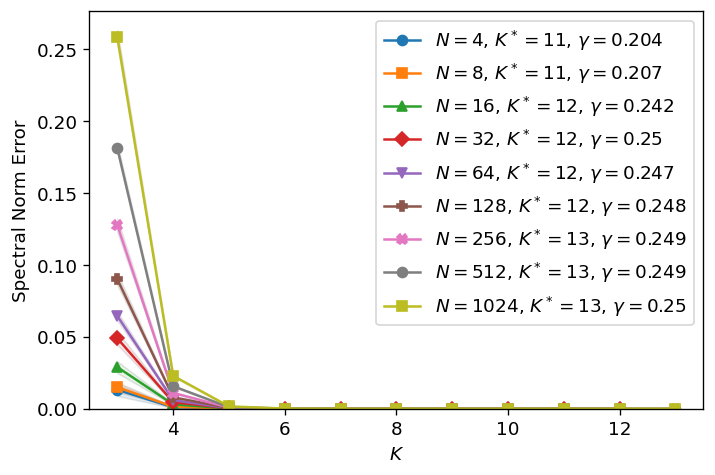

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


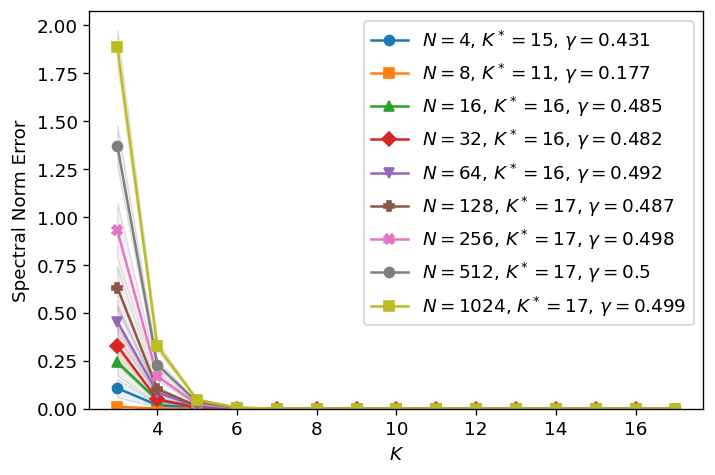

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


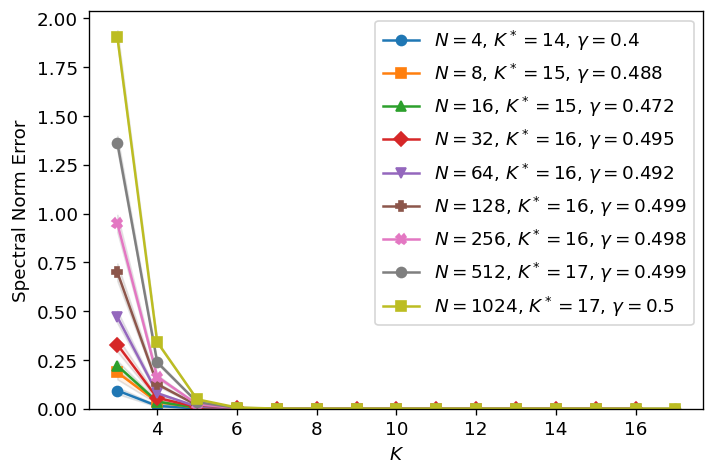

In [4]:
%matplotlib inline  

results = run_a1_experiment(
    n_values=[2, 3, 4, 5, 6, 7, 8, 9, 10],   # N = 2^n
    eps=1e-10,
    n_vecs=20,
    seed=0,
    out_dir=Path("figures/A1_lowrank_scaling"),
    show_figures=True,          # ensures inline display
)

In [5]:
print_gamma_kopt_table(results)

┌───────────┬──────┬──────────┬───────┐
│   Grid    │  N   │  gamma   │ K_opt │
├───────────┼──────┼──────────┼───────┤
│ perturbed │    4 │ 0.204042 │    11 │
│ perturbed │    8 │ 0.207175 │    11 │
│ perturbed │   16 │ 0.242076 │    12 │
│ perturbed │   32 │ 0.249588 │    12 │
│ perturbed │   64 │ 0.247343 │    12 │
│ perturbed │  128 │ 0.248133 │    12 │
│ perturbed │  256 │ 0.249381 │    13 │
│ perturbed │  512 │ 0.249438 │    13 │
│ perturbed │ 1024 │ 0.249769 │    13 │
│ clustered │    4 │ 0.431354 │    15 │
│ clustered │    8 │ 0.176826 │    11 │
│ clustered │   16 │ 0.485317 │    16 │
│ clustered │   32 │ 0.482142 │    16 │
│ clustered │   64 │ 0.491729 │    16 │
│ clustered │  128 │ 0.486906 │    17 │
│ clustered │  256 │ 0.498352 │    17 │
│ clustered │  512 │ 0.499534 │    17 │
│ clustered │ 1024 │ 0.499354 │    17 │
│ random    │    4 │ 0.399751 │    14 │
│ random    │    8 │ 0.488112 │    15 │
│ random    │   16 │  0.47168 │    15 │
│ random    │   32 │ 0.494685 │    16 │
